In [8]:
# %%
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 24,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 3,
})

# %%
# =============================================================================
# 2. Simulation Parameters & Paths
# =============================================================================
q_injection_scale_in_m  = 500.0  
ta_injection_scale_in_m = 200.0  
nside_grid = [256, 256, 256]
box_length = [2000., 2000., 4000.]
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  
time_utc = datetime(2023, 9, 3, 23, 0, tzinfo=timezone.utc)

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
apexfile   = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'



2.526086956521739 0.07649950269801416
Cloud cube generated with shape: (256, 256, 256)


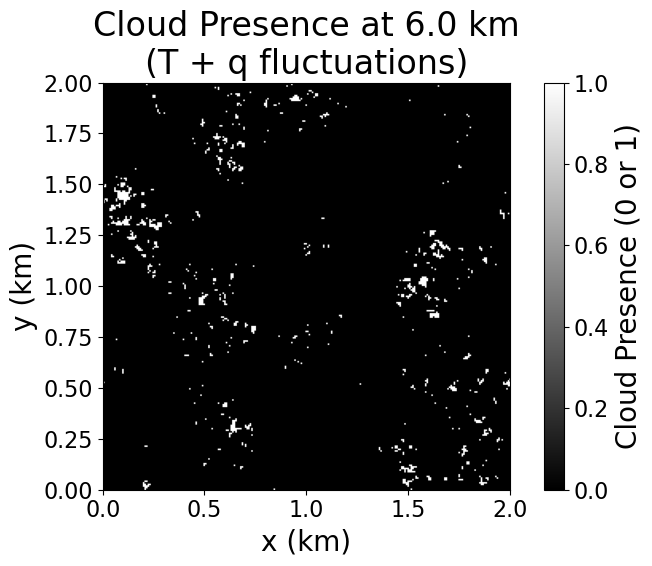

In [9]:
# =============================================================================
# 3. Initialize Atmosphere and Power Spectra
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

# Calculate power spectra
k_array = np.arange(nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)
k0_q  = 2*np.pi / q_injection_scale_in_m   
k0_ta = 2*np.pi / ta_injection_scale_in_m  

pofk_q  = (k0_q**2.  + k_array**2)**-(11/6)
pofk_ta = (k0_ta**2. + k_array**2)**-(11/6)
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}

# %%
# =============================================================================
# 4. Generate Primary Fields (Temperature & Water Vapor)
# =============================================================================
seed = 123456789

# Add components
atmo_box.add_watervapor(power_spec=pspec_q, seed=seed)
atmo_box.add_temperature(power_spec=pspec_ta, seed=seed)

# Generate 3D realizations (fluctuations + calibration)
atmo_box.generate_realization(time_step=0)

# %%
# =============================================================================
# 5. Derive the Cloud Mask
# =============================================================================
# This single call replaces all the manual RH calculation and quantile thresholding
cloud_cube = atmo_box.derive_cloud_mask(ccfile)

print(f"Cloud cube generated with shape: {cloud_cube.shape}")

# %%
# =============================================================================
# 6. Plotting the Results
# =============================================================================
altitude_profile = atmo_box.super_grid.z
altitude_level_km = 6.0
altitude_level_m = altitude_level_km * 1000.0

# Find the index in the altitude array that is closest to 6 km
altitude_index = jnp.argmin(jnp.abs(altitude_profile - altitude_level_m))

# Extract the 2D slice from the newly generated cloud mask
cloud_slice = cloud_cube[:, :, altitude_index]

plt.figure(figsize=(8,6))
plt.imshow(cloud_slice, origin='lower', cmap='gray',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'Cloud Presence at {altitude_level_km} km\n(T + q fluctuations)')
plt.colorbar(label='Cloud Presence (0 or 1)')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.tight_layout()
plt.show()

In [10]:
cubes = atmo_box.derive_liquid_ice_cubes(
    ccfile=ccfile, 
    ciwcfile=ciwcfile, 
    clwcfile=clwcfile
)

if 'ice' in cubes:
    ice_3d = cubes['ice']
    print(f"Generated Ice Cube: {ice_3d.shape}")

if 'liquid' in cubes:
    liquid_3d = cubes['liquid']
    print(f"Generated Liquid Cube: {liquid_3d.shape}")

Generated Ice Cube: (256, 256, 256)
Generated Liquid Cube: (256, 256, 256)


In [ ]:
#Let's plot a slice along x,z to see the vertical structure of the ice and liquid clouds
plt.figure

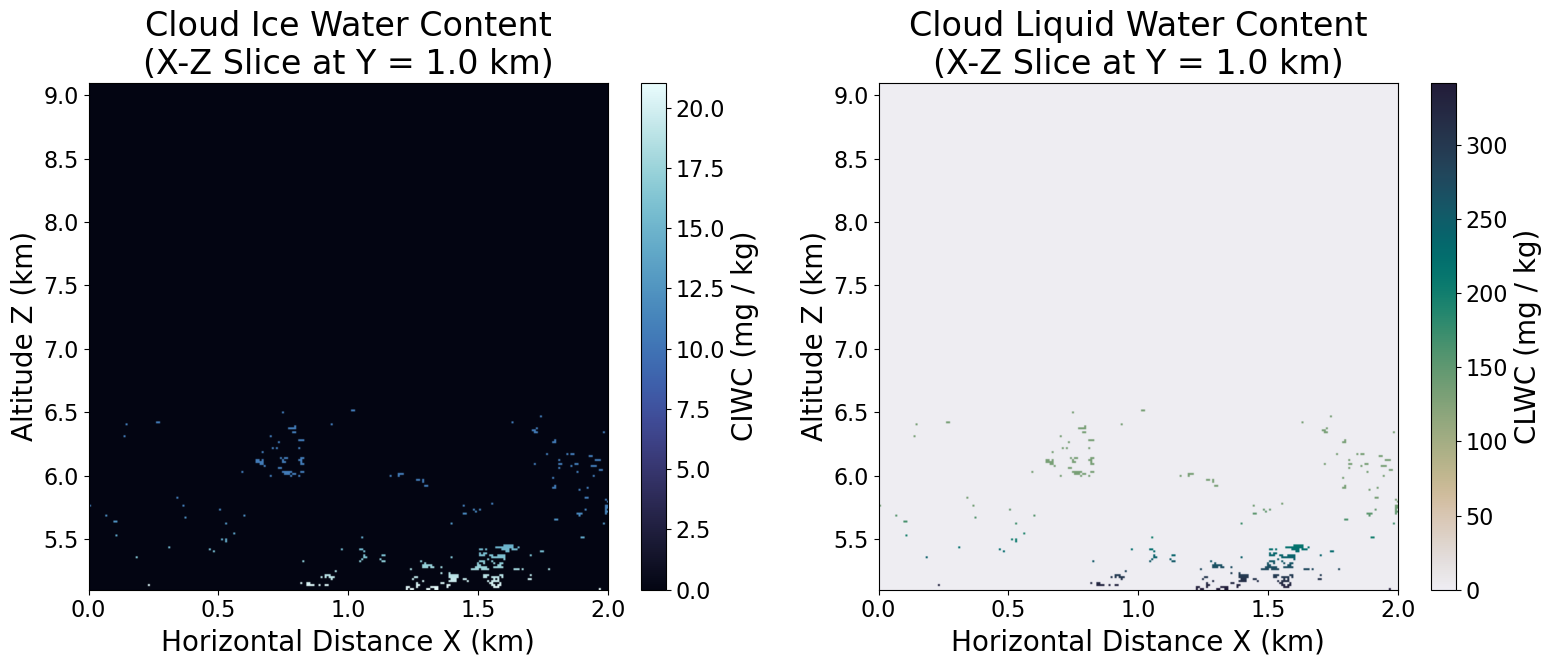

In [11]:
# Select a slice along the y-axis (e.g., right through the middle of the box)
y_index = nside_grid[1] // 2
y_level_km = (y_index / nside_grid[1]) * (box_length[1] / 1000)

# Check if the cubes exist in the dictionary returned by derive_liquid_ice_cubes
if 'ice' in cubes and 'liquid' in cubes:
    ice_3d = cubes['ice']
    liquid_3d = cubes['liquid']
    
    # Extract the X-Z slice: cube[:, y_index, :]
    # Transpose (.T) so Z is the vertical axis (rows) and X is horizontal (cols)
    # Multiply by 1e6 to convert from kg/kg to mg/kg for better readability
    ice_slice_xz = ice_3d[:, y_index, :].T * 1e6
    liquid_slice_xz = liquid_3d[:, y_index, :].T * 1e6
    
    # Define the bounding box for the plot axes in km
    # Z goes from the site altitude up to site altitude + box height
    x_min, x_max = 0, box_length[0] / 1000
    z_min = site_altitude / 1000
    z_max = (site_altitude + box_length[2]) / 1000
    plot_extent = [x_min, x_max, z_min, z_max]

    plt.figure(figsize=(16, 7))
    
    # ---------------------------------------------------------
    # 1. Plot Cloud Ice Water Content
    # ---------------------------------------------------------
    plt.subplot(1, 2, 1)
    # Using cmocean's 'ice' colormap
    im1 = plt.imshow(ice_slice_xz, origin='lower', cmap=cmo.cm.ice, 
                     aspect='auto', extent=plot_extent)
    plt.title(f'Cloud Ice Water Content\n(X-Z Slice at Y = {y_level_km:.1f} km)')
    plt.xlabel('Horizontal Distance X (km)')
    plt.ylabel('Altitude Z (km)')
    plt.colorbar(im1, label='CIWC (mg / kg)')
    
    # ---------------------------------------------------------
    # 2. Plot Cloud Liquid Water Content
    # ---------------------------------------------------------
    plt.subplot(1, 2, 2)
    # Using cmocean's 'rain' or 'haline' colormap for liquid
    im2 = plt.imshow(liquid_slice_xz, origin='lower', cmap=cmo.cm.rain, 
                     aspect='auto', extent=plot_extent)
    plt.title(f'Cloud Liquid Water Content\n(X-Z Slice at Y = {y_level_km:.1f} km)')
    plt.xlabel('Horizontal Distance X (km)')
    plt.ylabel('Altitude Z (km)')
    plt.colorbar(im2, label='CLWC (mg / kg)')
    
    plt.tight_layout()
    plt.show()

else:
    print("Ice or liquid cubes are missing from the dictionary! Make sure they were successfully generated.")